# Load data

In [5]:
!pip install "etna[prophet]" -q
!pip uninstall prophet -y -q
!pip install "prophet>=1.1.5" -q


In [ ]:
import warnings

warnings.filterwarnings("ignore")

Let's load and prepare the data.

In [1]:
#
# Шаг 1. Генерация данных
#
import numpy as np
import pandas as pd
from etna.datasets import TSDataset
from etna.transforms import (
    LogTransform,
    LinearTrendTransform,
    FourierTransform,
    DateFlagsTransform,
    LagTransform,
    MeanTransform,
    # BinsregTrendTransform,
    TheilSenTrendTransform
)
from etna.models import CatBoostMultiSegmentModel
from etna.pipeline import Pipeline
from etna.analysis import plot_trend

# Параметры
np.random.seed(42)
n = 365 * 2  # 2 года ежедневных данных
dates = pd.date_range("2020-01-01", periods=n, freq="D")

# Тренд: экспоненциальный рост
trend = 100 * np.exp(0.002 * np.arange(n))

# Сезонность: недельная + годовая
season_weekly = 15 * np.sin(2 * np.pi * np.arange(n) / 7)
season_yearly = 25 * np.sin(2 * np.pi * np.arange(n) / 365.25)

# Шум
noise = np.random.normal(0, 4, n)

# Целевая переменная
y = trend + season_weekly + season_yearly + noise

# Формат для ETNA: требуется колонка "segment"
df = pd.DataFrame({
    "timestamp": dates,
    "segment": "product_A",  # можно добавить несколько сегментов
    "target": y
})

# Создаём TSDataset
ts = TSDataset(df=TSDataset.to_dataset(df), freq="D")

/usr/local/lib/python3.12/dist-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:89: UserWarning: etna[classification] is not available, to install it, run `pip install etna[classification]`
  warnings.warn("etna[classification] is not available, to install it, run `pip install etna[classification]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:98: UserWarning: etna[auto] is not available, to install it, run `pip install etna[auto]`
  warnings.warn("etna[auto] is not available, to install it, run `pip install etna[auto]`")
/usr/local/lib/python3.12/dist-packages/etna/settings.py:115: UserWarning: etna[clearml] is not available, to install it, run `pip install etna[clearml]`
  warnings.warn("etna[clearml] is not available, to install it, run `pip install etna

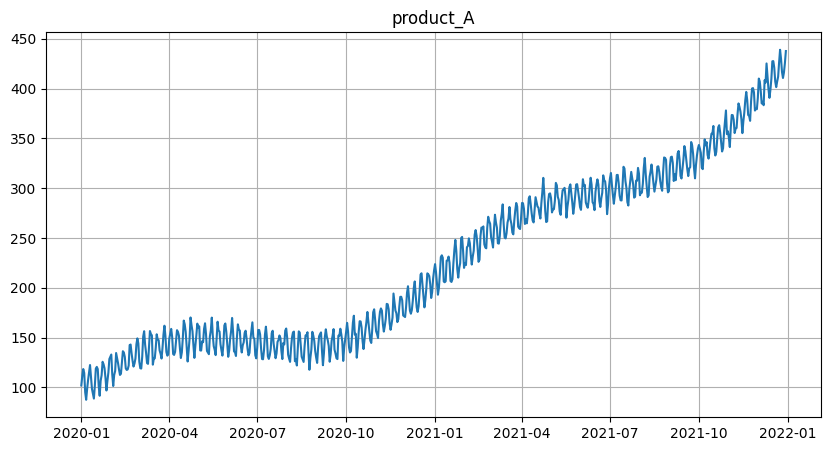

In [2]:
ts.plot()

#ProphetModel

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


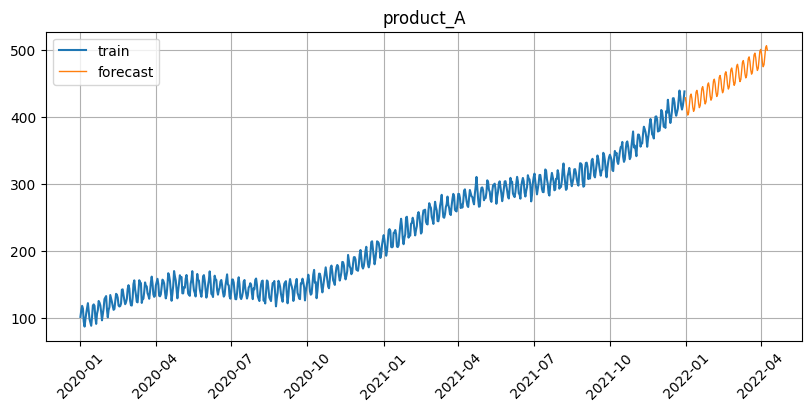

In [3]:
from etna.analysis import plot_forecast
from etna.models import ProphetModel

HORIZON=100
model = ProphetModel()
pipeline = Pipeline(model=model, horizon=HORIZON)
pipeline.fit(ts)
forecast_ts_ProphetModel = pipeline.forecast()

plot_forecast(
    forecast_ts=forecast_ts_ProphetModel,
    train_ts=ts,
    # n_train_samples=365,
    figsize=(8,4)
)


#CatBoostMultiSegmentModel

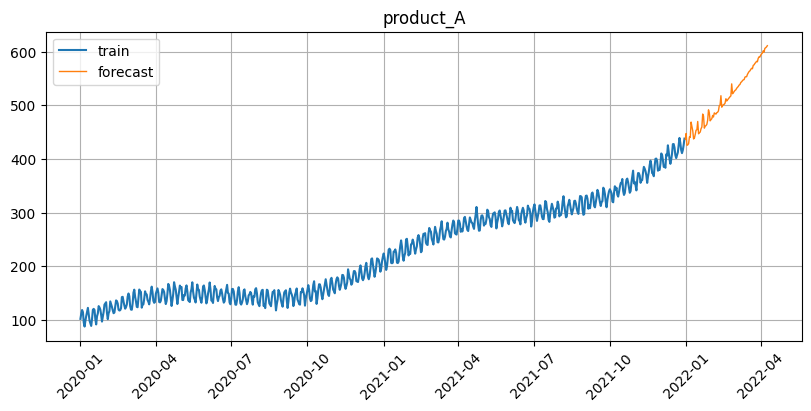

In [4]:
from etna.transforms import (
    LogTransform,
    TheilSenTrendTransform,
    FourierTransform,
    LagTransform,
    MeanTransform,
    DateFlagsTransform,
    LinearTrendTransform
)
from etna.models import CatBoostMultiSegmentModel
from etna.models import CatBoostPerSegmentModel
from etna.pipeline import Pipeline
from etna.metrics import MAE

HORIZON=100

# Шаг 1. Применяем трансформации
transforms = [
    LogTransform(in_column="target"),  # стабилизация дисперсии + линеаризация тренда
    TheilSenTrendTransform(in_column="target", random_state=42),  # выделяем линейный тренд (можно оставить)
    # LinearTrendTransform(in_column="target"),
    # FourierTransform(in_column="target", period=365.25, order=30),  # годовая сезонность
    # FourierTransform(in_column="target", period=7, order=3),        # недельная сезонность
    LagTransform(in_column="target", lags=[1, 7, 14, 28, 56, 365]),  # важные лаги
    # MeanTransform(in_column="target", window=7),                 # скользящее среднее за неделю
    # MeanTransform(in_column="target", window=30),                # за месяц
    # DateFlagsTransform(
    #     # day_number_in_week=True,
    #     # day_number_in_month =True,
    #     # day_number_in_year =True,
    #     # week_number_in_month =True,
    #     # week_number_in_year =True,
    #     # month_number_in_year =True,
    #     # is_weekend=True,
    # ),                                        # день недели, месяц и т.д.
]

# Шаг 2. Создаем pipeline
model = CatBoostPerSegmentModel(
    iterations=100,
    random_state=42,
    thread_count=-1
)

pipeline = Pipeline(
    model=model,
    transforms=transforms,
    horizon=HORIZON,   # прогноз на 100 дней вперед
)
pipeline.fit(ts)
forecast_ts = pipeline.forecast()
plot_forecast(
    forecast_ts=forecast_ts,
    train_ts=ts,
    # n_train_samples=365,
    figsize=(8,4)
)

#DANO 2025-5

In [6]:
!pip install "etna[prophet]" -q
!pip uninstall prophet -y -q
!pip install "prophet>=1.1.5" -q
import warnings
warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.2/565.2 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [13]:
import pandas as pd
df = pd.read_csv('/content/task_4_before.csv')
df

,Unnamed: 0,date,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10
0,0,0,0,400,117,53,38,189,225,16,185,137
1,1,1,2,396,122,47,62,200,239,31,186,175
2,2,2,4,392,124,50,59,189,229,15,195,165
3,3,3,6,388,130,51,57,187,230,16,191,152
4,4,4,8,384,130,52,40,176,225,13,188,137
...,...,...,...,...,...,...,...,...,...,...,...,...
58,58,58,116,168,294,51,122,78,287,23,227,231
59,59,59,118,164,296,46,111,76,292,27,233,214
60,60,60,120,160,301,46,94,60,275,5,231,179
61,61,61,122,156,304,52,86,74,295,21,230,164


In [ ]:
df['timestamp'] = pd.date_range(start='2000-01-01', periods=len(df), freq='D')
df.head()

In [15]:
df = df.drop(columns=['Unnamed: 0', 'date'])
df.head()

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,timestamp
0,0,400,117,53,38,189,225,16,185,137,2000-01-01
1,2,396,122,47,62,200,239,31,186,175,2000-01-02
2,4,392,124,50,59,189,229,15,195,165,2000-01-03
3,6,388,130,51,57,187,230,16,191,152,2000-01-04
4,8,384,130,52,40,176,225,13,188,137,2000-01-05


In [16]:
df_long = df.melt(id_vars=['timestamp'], var_name='segment', value_name='target')
df_long.head()

,timestamp,segment,target
0,2000-01-01,item1,0
1,2000-01-02,item1,2
2,2000-01-03,item1,4
3,2000-01-04,item1,6
4,2000-01-05,item1,8


In [17]:
from etna.datasets import TSDataset
ts = TSDataset(df_long, freq="D")

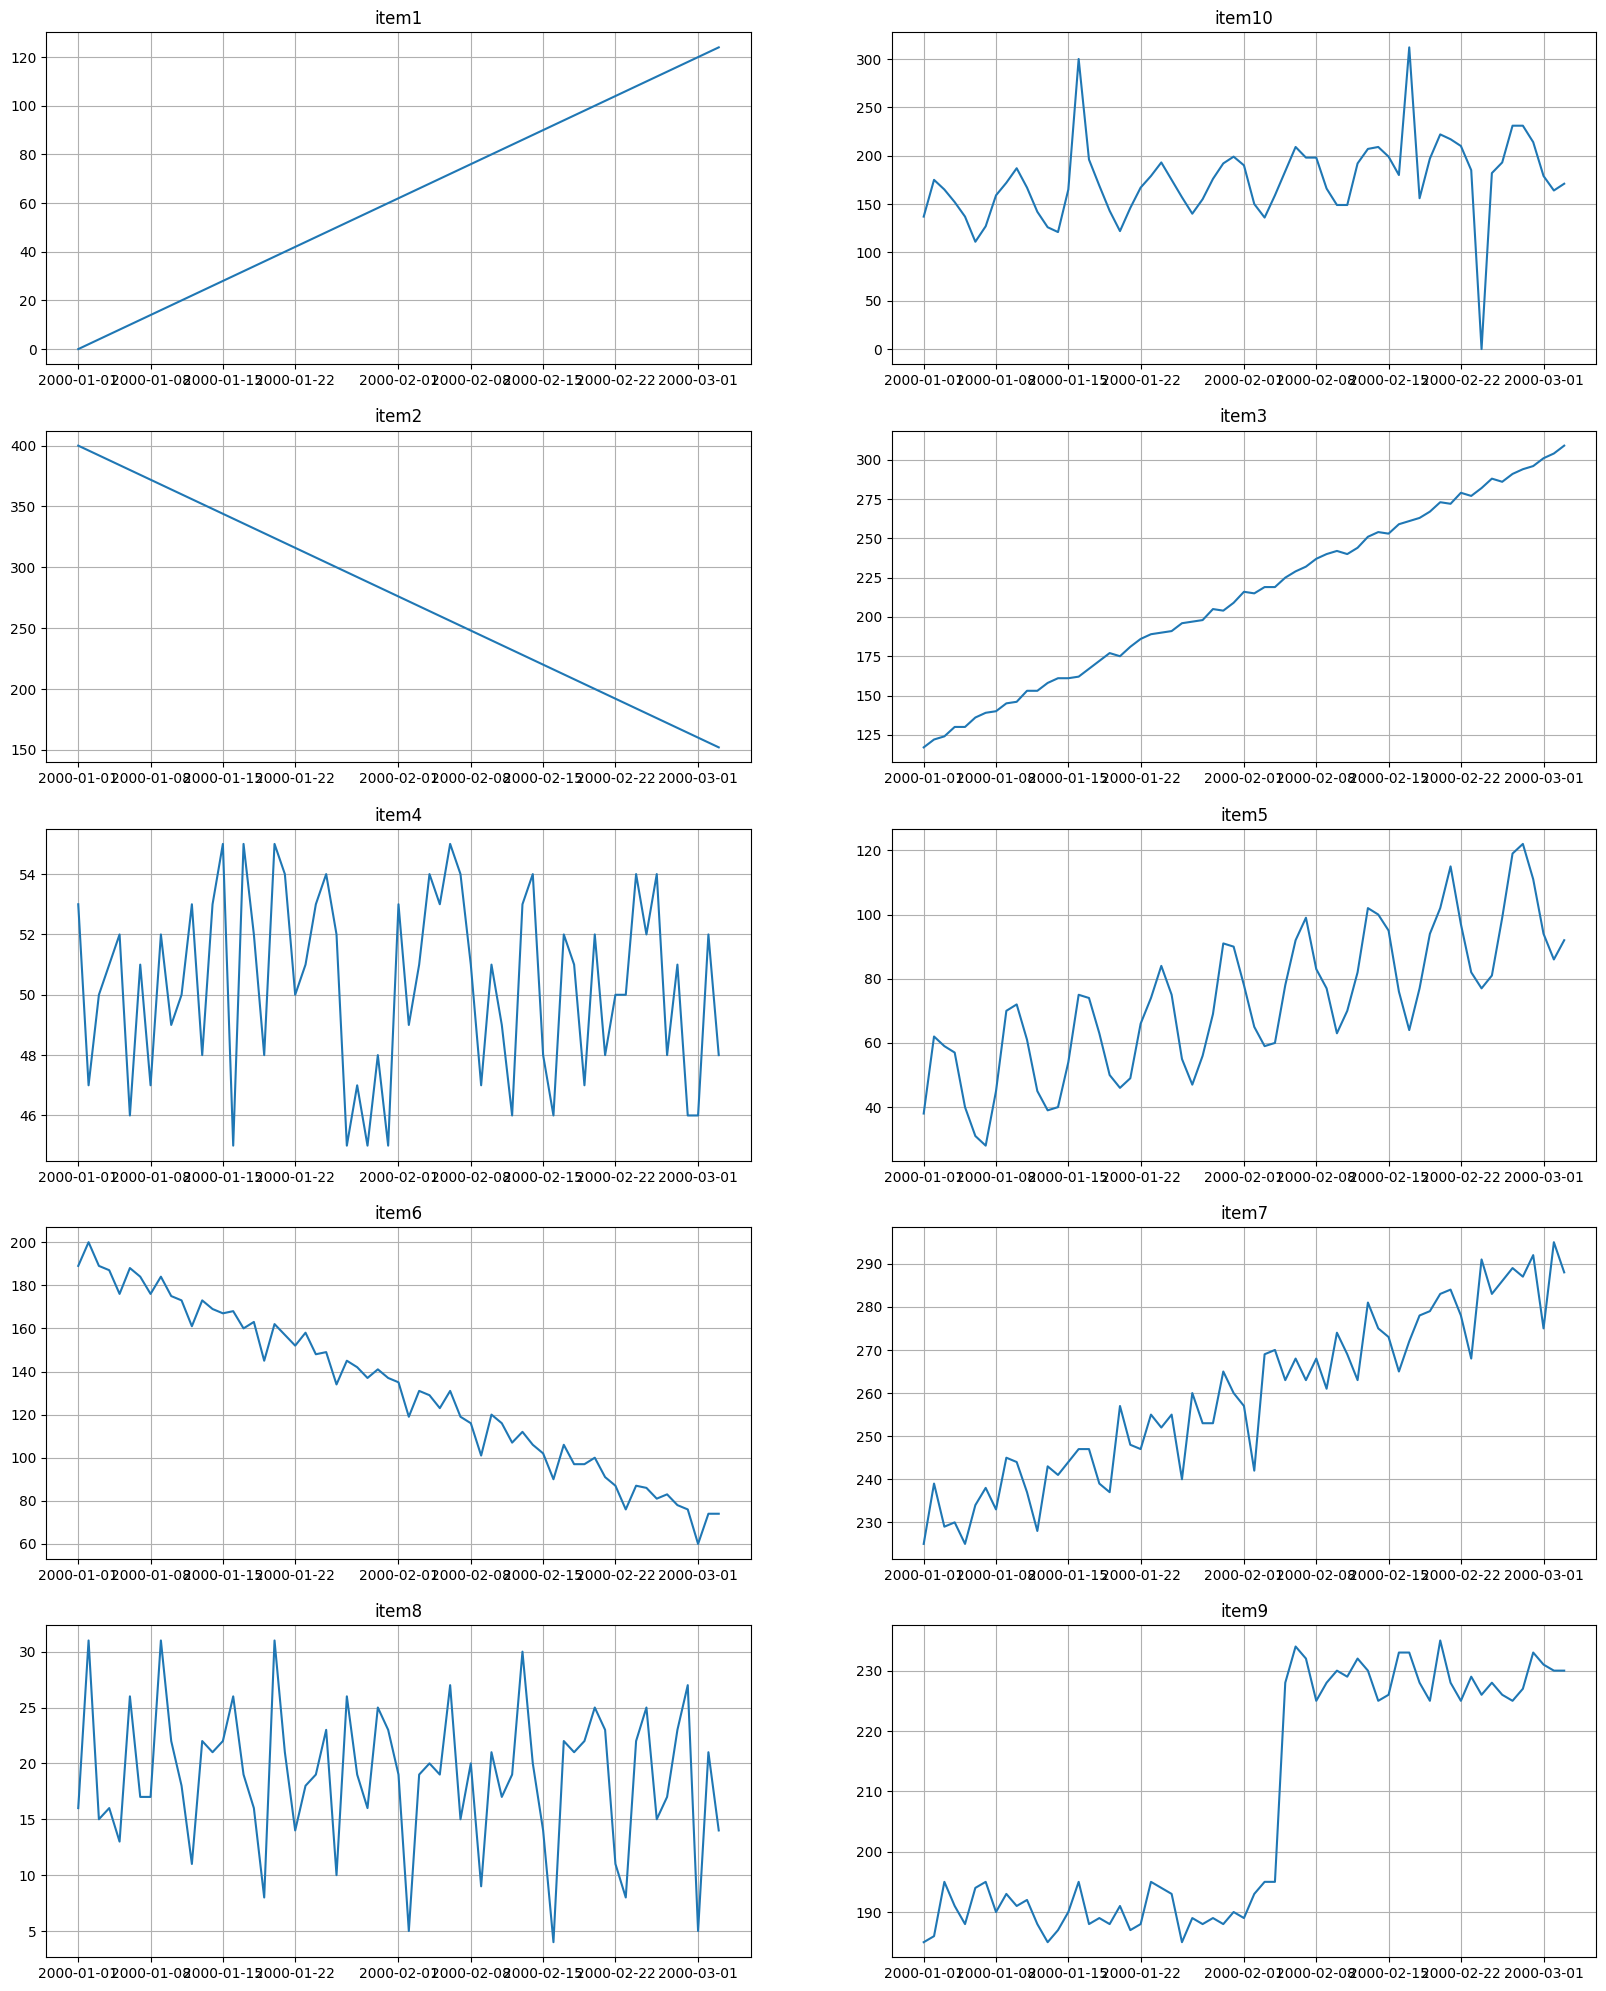

In [18]:
ts.plot()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

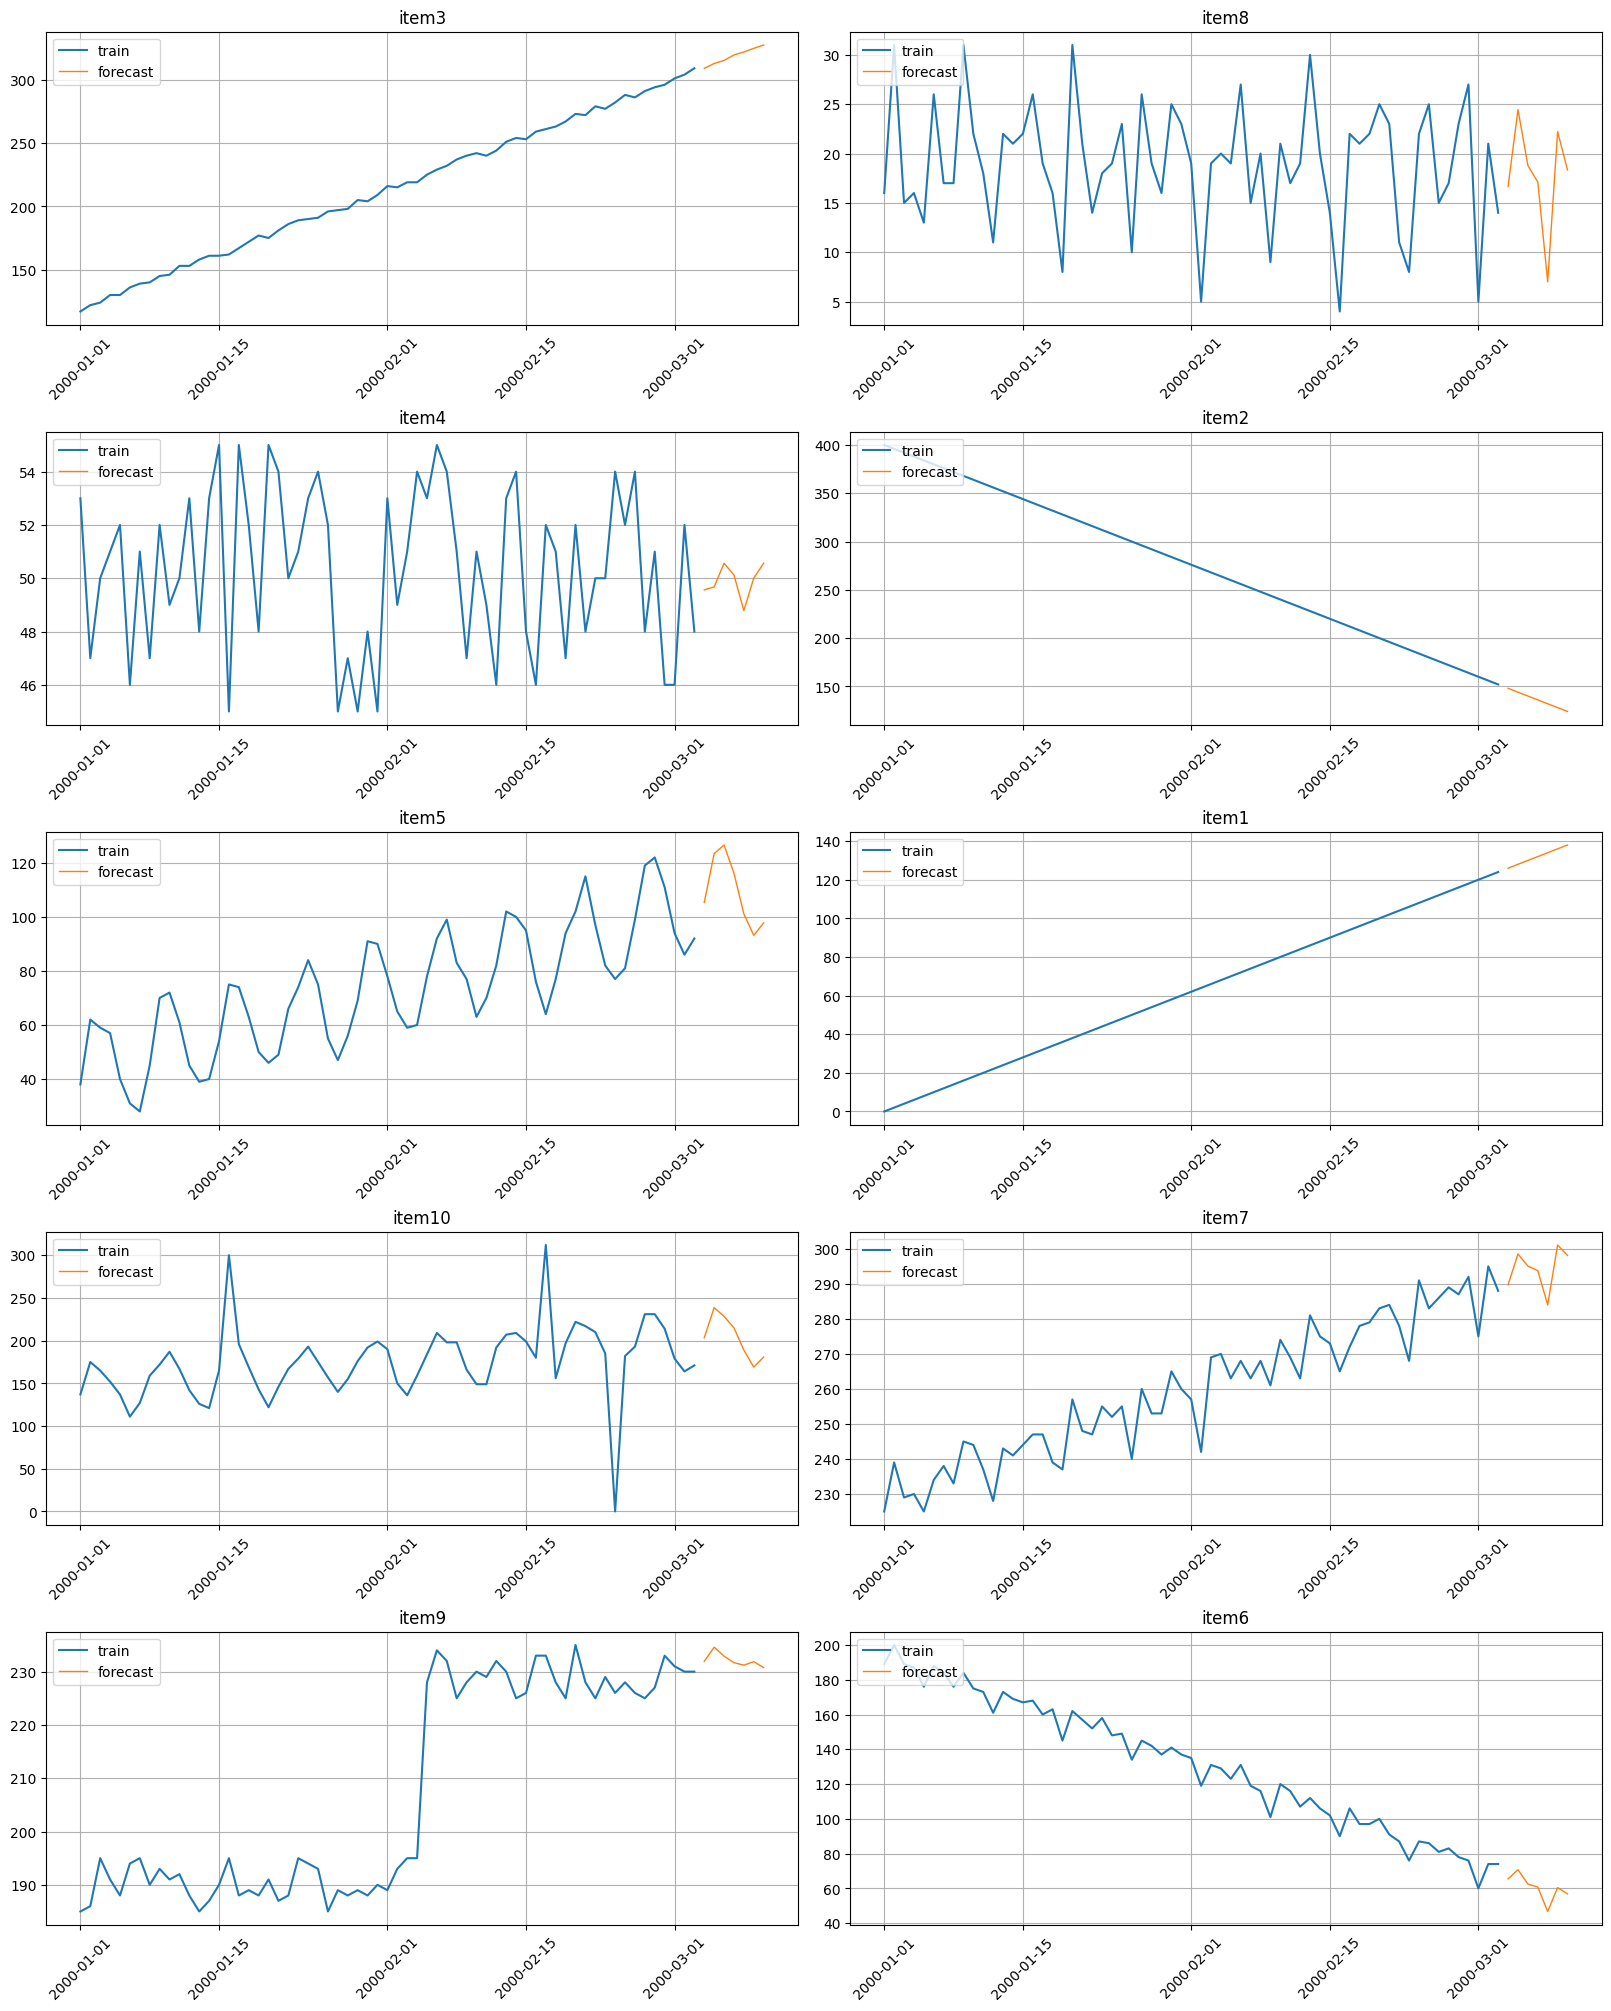

In [19]:
from etna.analysis import plot_forecast
from etna.models import ProphetModel
from etna.pipeline import Pipeline

HORIZON=7
model = ProphetModel()
pipeline = Pipeline(model=model, horizon=HORIZON)
pipeline.fit(ts)
forecast_ts_ProphetModel = pipeline.forecast()

plot_forecast(
    forecast_ts=forecast_ts_ProphetModel,
    train_ts=ts,
    figsize=(8,4)
)
